# Analisis Dataset Bank

## Pertemuan 07 - Data Exploration dan Profiling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load dataset
df = pd.read_csv('data-bank.csv')
print("✓ Dataset berhasil dimuat")

✓ Dataset berhasil dimuat


## 1. Informasi Dasar Dataset

In [2]:
print("INFORMASI DATASET")
print("="*60)
print(f"Dimensi: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\nTipe data:")
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

INFORMASI DATASET
Dimensi: 6819 baris × 96 kolom

Tipe data:
float64    93
int64       3
Name: count, dtype: int64

Memory usage: 4.99 MB


In [3]:
# Tampilkan beberapa baris pertama
print("\n5 BARIS PERTAMA:")
print("="*60)
print(df.head())

# Tampilkan nama kolom
print("\n\nNAMA KOLOM:")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")


5 BARIS PERTAMA:
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                               

## 2. Analisis Missing Values (Data Kosong)

In [4]:
print("ANALISIS MISSING VALUES")
print("="*60)
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolom': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing %': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print("✓ Tidak ada missing values dalam dataset ini!")
else:
    print(missing_df.to_string(index=False))

ANALISIS MISSING VALUES
✓ Tidak ada missing values dalam dataset ini!


## 3. Statistik Deskriptif

In [5]:
print("STATISTIK DESKRIPTIF DATASET")
print("="*80)
print(df.describe().T)

STATISTIK DESKRIPTIF DATASET
                                                     count          mean  \
Bankrupt?                                           6819.0  3.226280e-02   
 ROA(C) before interest and depreciation before...  6819.0  5.051796e-01   
 ROA(A) before interest and % after tax             6819.0  5.586249e-01   
 ROA(B) before interest and depreciation after tax  6819.0  5.535887e-01   
 Operating Gross Margin                             6819.0  6.079480e-01   
 Realized Sales Gross Margin                        6819.0  6.079295e-01   
 Operating Profit Rate                              6819.0  9.987551e-01   
 Pre-tax net Interest Rate                          6819.0  7.971898e-01   
 After-tax net Interest Rate                        6819.0  8.090836e-01   
 Non-industry income and expenditure/revenue        6819.0  3.036229e-01   
 Continuous interest rate (after tax)               6819.0  7.813814e-01   
 Operating Expense Rate                             6819.0 

## 4. Analisis Kolom Target (Bankrupt?)

In [6]:
# Kolom pertama adalah target variable
target_col = df.columns[0]
print(f"TARGET VARIABLE: '{target_col}'")
print("="*60)

# Distribusi target
target_counts = df[target_col].value_counts().sort_index()
print("\nDistribusi Kelas:")
for idx, count in target_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {target_col}={int(idx)}: {count:5} samples ({pct:6.2f}%)")

# Imbalance ratio
if len(target_counts) == 2:
    ratio = target_counts.iloc[1] / target_counts.iloc[0]
    print(f"\nImbalance Ratio: {ratio:.4f}")
    print(f"{'⚠ Dataset sangat imbalanced!' if ratio < 0.2 or ratio > 5 else '✓ Dataset relatif balanced'}")

TARGET VARIABLE: 'Bankrupt?'

Distribusi Kelas:
  Bankrupt?=0:  6599 samples ( 96.77%)
  Bankrupt?=1:   220 samples (  3.23%)

Imbalance Ratio: 0.0333
⚠ Dataset sangat imbalanced!


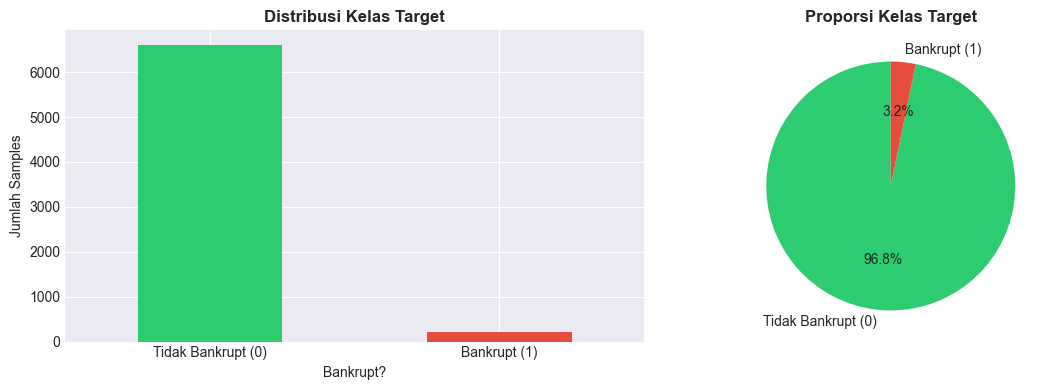

In [7]:
# Visualisasi distribusi target
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribusi Kelas Target', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Bankrupt?')
ax[0].set_ylabel('Jumlah Samples')
ax[0].set_xticklabels(['Tidak Bankrupt (0)', 'Bankrupt (1)'], rotation=0)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
ax[1].pie(target_counts.values, labels=['Tidak Bankrupt (0)', 'Bankrupt (1)'], 
          autopct='%1.1f%%', colors=colors, startangle=90)
ax[1].set_title('Proporsi Kelas Target', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Analisis Outliers dan Data Quality

In [8]:
# Deteksi outliers menggunakan IQR method
print("DETEKSI OUTLIERS (IQR Method)")
print("="*80)

outlier_cols = df.columns[1:]  # Exclude target variable
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df)) * 100
    
    if outliers > 0:
        outlier_summary.append({
            'Kolom': col,
            'Outliers': outliers,
            'Pct': f"{outlier_pct:.2f}%"
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).head(20)
    print(outlier_df.to_string(index=False))
    print(f"\n... ({len(outlier_summary)} kolom memiliki outliers)")
else:
    print("Tidak ada outliers yang terdeteksi")

DETEKSI OUTLIERS (IQR Method)
                                                   Kolom  Outliers    Pct
 ROA(C) before interest and depreciation before interest       391  5.73%
                  ROA(A) before interest and % after tax       561  8.23%
       ROA(B) before interest and depreciation after tax       432  6.34%
                                  Operating Gross Margin       320  4.69%
                             Realized Sales Gross Margin       318  4.66%
                                   Operating Profit Rate       716 10.50%
                               Pre-tax net Interest Rate       773 11.34%
                             After-tax net Interest Rate       867 12.71%
             Non-industry income and expenditure/revenue      1094 16.04%
                    Continuous interest rate (after tax)       806 11.82%
                   Research and development expense rate       182  2.67%
                                          Cash flow rate       576  8.45%
        

In [9]:
# Statistik data quality
print("\n\nKUALITAS DATA")
print("="*80)

quality_metrics = {
    'Total Rows': len(df),
    'Total Columns': len(df.columns),
    'Total Missing': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Data Types': len(df.dtypes.unique()),
}

for metric, value in quality_metrics.items():
    print(f"{metric:20}: {value:,}")



KUALITAS DATA
Total Rows          : 6,819
Total Columns       : 96
Total Missing       : 0
Duplicate Rows      : 0
Data Types          : 2


## 6. Distribusi Fitur (Feature Distribution)

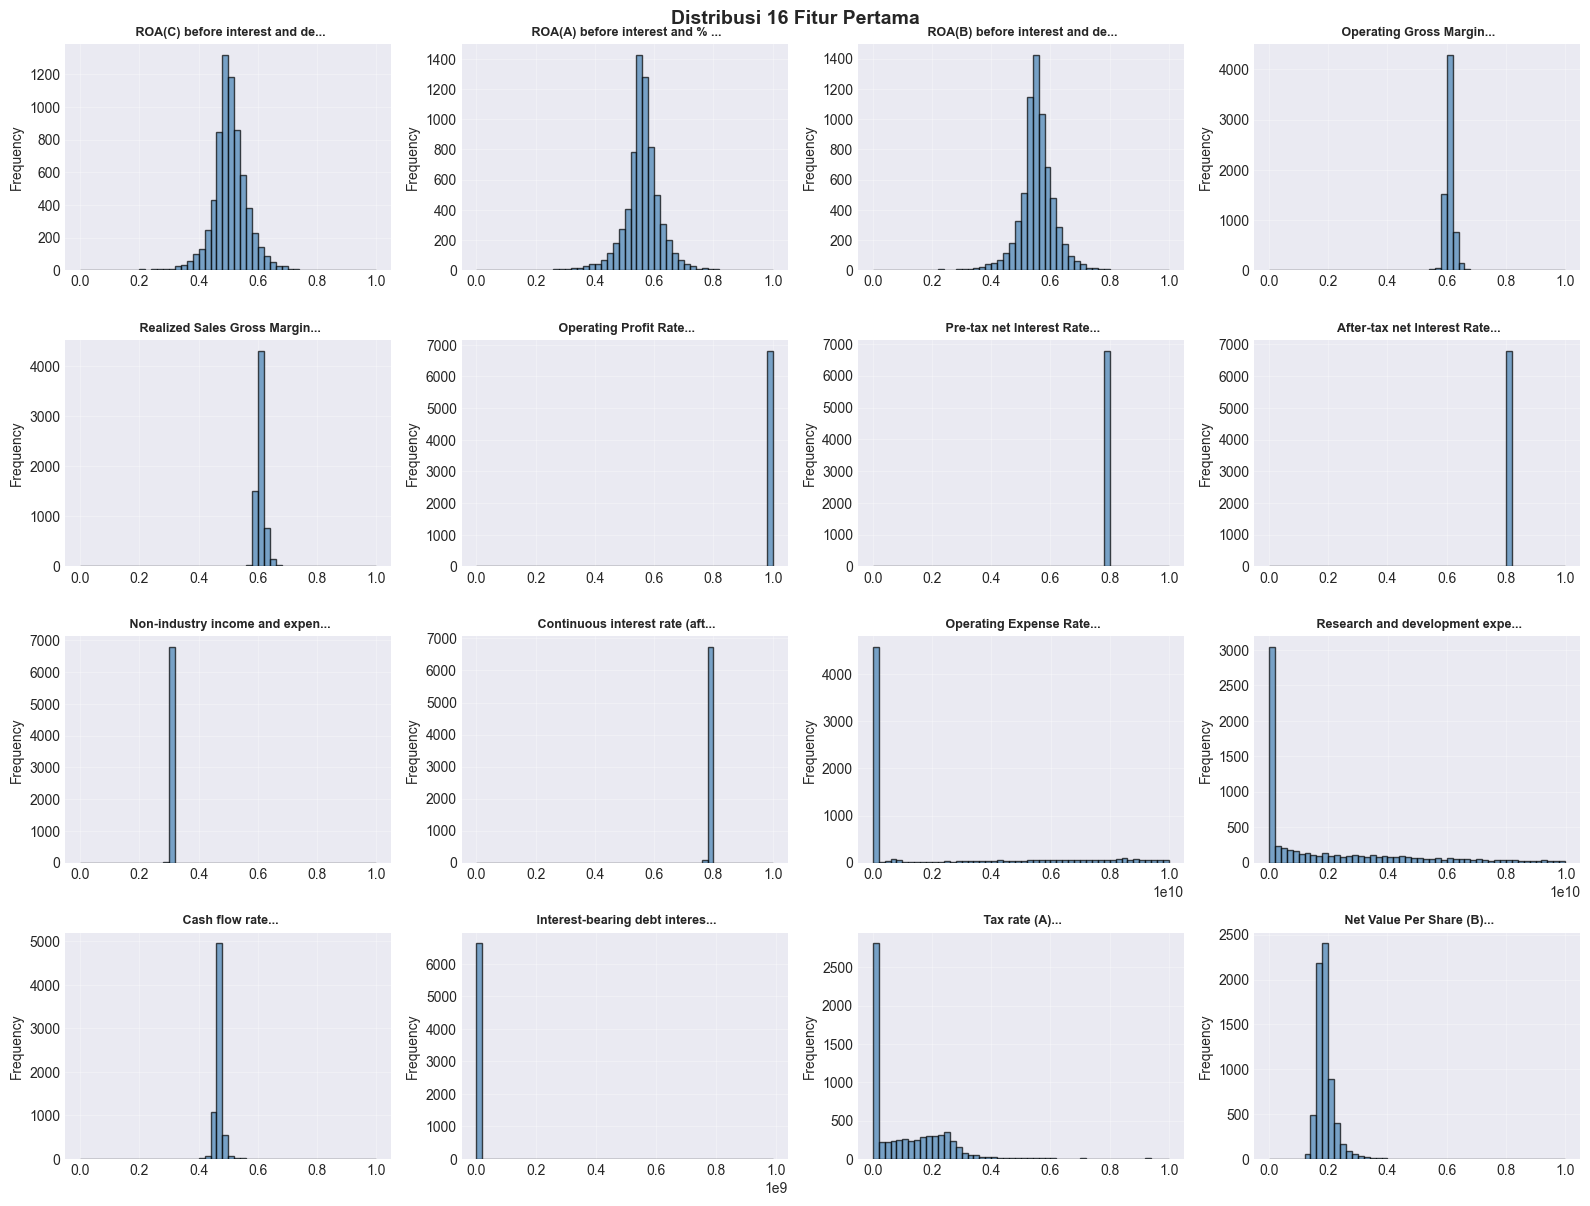

In [10]:
# Visualisasi distribusi beberapa fitur pertama
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns[1:17]):  # 16 fitur pertama
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col[:30]}...', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribusi 16 Fitur Pertama', fontsize=14, fontweight='bold', y=1.001)
plt.show()

## 7. Analisis Korelasi

In [11]:
# Analisis korelasi dengan target
correlation_with_target = df.corr()[target_col].drop(target_col).sort_values(ascending=False)

print("KORELASI FITUR DENGAN TARGET VARIABLE")
print("="*80)
print("\nTop 20 Fitur dengan Korelasi Tertinggi (Positif):")
print(correlation_with_target.head(20))
print("\nTop 20 Fitur dengan Korelasi Terendah (Negatif):")
print(correlation_with_target.tail(20))

KORELASI FITUR DENGAN TARGET VARIABLE

Top 20 Fitur dengan Korelasi Tertinggi (Positif):
Debt ratio %                                   0.250161
Current Liability to Assets                    0.194494
Borrowing dependency                           0.176543
Current Liability to Current Assets            0.171306
Liability to Equity                            0.166812
Current Liabilities/Equity                     0.153828
Current Liability to Equity                    0.153828
Liability-Assets Flag                          0.139212
Total expense/Assets                           0.139049
Equity to Long-term Liability                  0.139014
Cash/Current Liability                         0.077921
Inventory and accounts receivable/Net value    0.075278
Fixed Assets Turnover Frequency                0.072818
Contingent liabilities/Net worth               0.070455
Fixed Assets to Assets                         0.066328
Net Value Growth Rate                          0.065329
Revenue per per

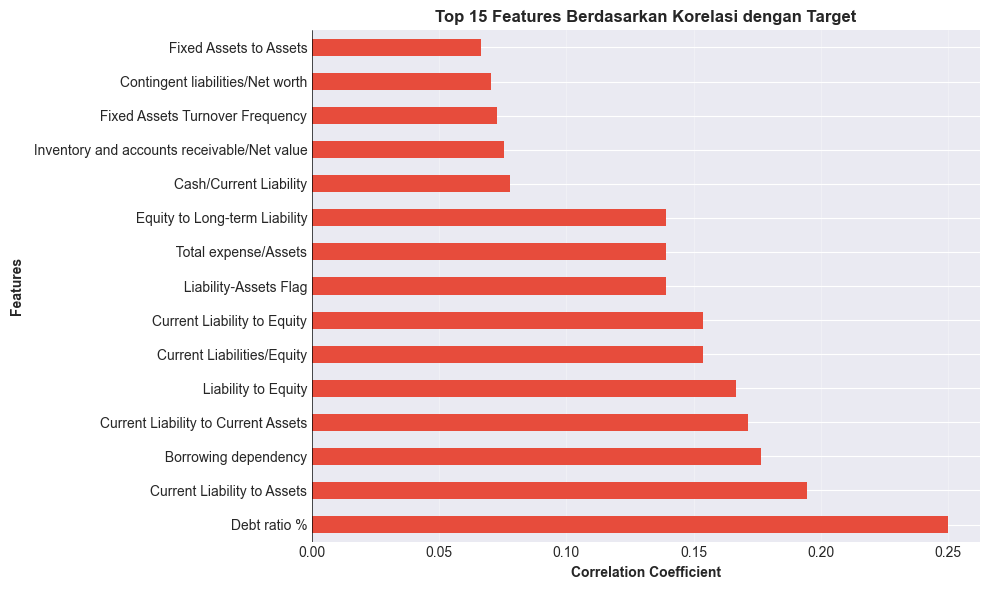

In [12]:
# Visualisasi korelasi top 15 fitur
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = correlation_with_target.head(15)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation Coefficient', fontweight='bold')
ax.set_ylabel('Features', fontweight='bold')
ax.set_title('Top 15 Features Berdasarkan Korelasi dengan Target', fontweight='bold', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Ringkasan Insight & Rekomendasi

In [13]:
print("\n" + "="*80)
print("RINGKASAN INSIGHT & REKOMENDASI")
print("="*80)

insights = f"""
📊 DATASET OVERVIEW:
  • Dimensi: {df.shape[0]:,} baris × {df.shape[1]:,} kolom
  • Target Variable: '{target_col}' (Klasifikasi Biner)
  • Tidak ada missing values
  • Semua fitur adalah numerik (float64)

🎯 TARGET VARIABLE:
  • Kelas 0 (Tidak Bankrupt): {target_counts.iloc[0]:,} sampel ({(target_counts.iloc[0]/len(df)*100):.2f}%)
  • Kelas 1 (Bankrupt): {target_counts.iloc[1]:,} sampel ({(target_counts.iloc[1]/len(df)*100):.2f}%)
  
  {'⚠️  CATATAN: Dataset sangat imbalanced! Perlu strategi resampling' if (target_counts.iloc[1]/target_counts.iloc[0]) < 0.3 else '✓ Dataset relatif balance'}

📈 FITUR ENGINEERING:
  • Total fitur: {len(df.columns)-1:,}
  • Top 3 fitur berkorelasi positif dengan target:
    1. {correlation_with_target.index[0]} ({correlation_with_target.values[0]:.4f})
    2. {correlation_with_target.index[1]} ({correlation_with_target.values[1]:.4f})
    3. {correlation_with_target.index[2]} ({correlation_with_target.values[2]:.4f})

⚠️  REKOMENDASI:
  1. Lakukan feature scaling/normalization sebelum modeling (Range: 0-1 atau Z-score)
  2. Gunakan strategi resampling (SMOTE/RandomOverSampler) untuk mengatasi imbalance
  3. Lakukan feature selection untuk mengurangi dimensionalitas
  4. Cek multicollinearity antar fitur sebelum modeling
  5. Gunakan cross-validation untuk evaluasi model
"""

print(insights)


RINGKASAN INSIGHT & REKOMENDASI

📊 DATASET OVERVIEW:
  • Dimensi: 6,819 baris × 96 kolom
  • Target Variable: 'Bankrupt?' (Klasifikasi Biner)
  • Tidak ada missing values
  • Semua fitur adalah numerik (float64)

🎯 TARGET VARIABLE:
  • Kelas 0 (Tidak Bankrupt): 6,599 sampel (96.77%)
  • Kelas 1 (Bankrupt): 220 sampel (3.23%)

  ⚠️  CATATAN: Dataset sangat imbalanced! Perlu strategi resampling

📈 FITUR ENGINEERING:
  • Total fitur: 95
  • Top 3 fitur berkorelasi positif dengan target:
    1.  Debt ratio % (0.2502)
    2.  Current Liability to Assets (0.1945)
    3.  Borrowing dependency (0.1765)

⚠️  REKOMENDASI:
  1. Lakukan feature scaling/normalization sebelum modeling (Range: 0-1 atau Z-score)
  2. Gunakan strategi resampling (SMOTE/RandomOverSampler) untuk mengatasi imbalance
  3. Lakukan feature selection untuk mengurangi dimensionalitas
  4. Cek multicollinearity antar fitur sebelum modeling
  5. Gunakan cross-validation untuk evaluasi model

